<h1> Detecting, flagging, and classifying pollution events</h1>

<p>Let's start by reading in our sample black carbon data and configuration file.</p>

In [1]:
import airinsights as air

input_data, config = air.read_aqdata_file(input_file="sample_data/oakland_2017_100x100_blackcarbon.csv",
                                          config="../config/example_config_output.yaml")

Melting data to long format
Timestamp already in local timezone: America/Los_Angeles


The <code>pollution_event()</code> function calculates the median, median absolute deviation (MAD), and modified Z-score for each monitor by hour of day
to compare individual monitor observations to the monitor's historic observations at each hour of day.

<small><code>help(air.pollution_event)</code> for more detail on the methodology.</small>

In [2]:
# Returns site, timestamp, pollutant name, modified z-score, and a description of the event
events = air.pollution_event(input_data, config)

# Join the event flags back to the original dataframe 
df_events = input_data.merge(events,
                  on = [config['site_col'],
                        config['timestamp_col'],
                        config['pollutant_col']],
                  how = "left")

# Show a random sample of the processed data
print("Event flags joined back to the original dataframe:")
df_events.sample(5)

Event flags joined back to the original dataframe:


,Datetime,Site,Latitude,Longitude,pollutant,value,z_score_mod,event_type
142432,2017-06-22 16:00:00-07:00,60,37.81996,-122.29177,hourly_BC,0.53,NaN,Insufficient number of days captured
235608,2017-06-05 00:00:00-07:00,99,37.80687,-122.28006,hourly_BC,0.16,NaN,Insufficient number of days captured
232021,2017-07-25 13:00:00-07:00,97,37.81027,-122.27974,hourly_BC,0.48,0.527674,NaN
118752,2017-07-06 00:00:00-07:00,50,37.80062,-122.32959,hourly_BC,NaN,NaN,NaN
78122,2017-07-13 02:00:00-07:00,33,37.81385,-122.29210,hourly_BC,0.41,0.663362,NaN


<p>If the input data references sensors in the same general area, like a city or county, Air Insights can aggregate and classify events within your sensor network.

The <code>classify_pollution_events()</code> function runs the <i>pollution_event</i> function internally, then groups them into more interpretable 'Regional' and 'Local' events based on distance and time. This is useful for distinguishing widespread pollution events (e.g. wildfire smoke) from more localized sources (e.g. railyards or construction sites). 

<small><code>help(classify_pollution_events)</code> for more detail on the methodology.</small>

In [3]:
summary, df = air.classify_pollution_events(df_events, config)

Median of 33.0 sites per timestamp with hourly_BC data, continuing with regional vs. local classification
Some timestamps have less than 3 site measurements and will be skipped


The function returns two dataframes:
<br>
&emsp;1.<b> summary</b> - A pandas DataFrame with one row per classified pollution event and the following columns:
<ul>
    <li>event_ID: unique identifier for the event, prefixed by scale and pollutant (e.g. "REG_PM2.5_0", "LOC_PM2.5_3") </li>
    <li>start_time, end_time: start and end times of the pollution event </li>
    <li>event_scale: "Regional" or "Local" </li>
    <li>sites: "Network-wide" for Regional events, or a comma-separated list of sites for Local events </li>
    <li>peak_value: maximum measured value observed during the event </li>
    <li>typical_value_at_peak: the network's (Regional) or site's (Local) typical value for the peak's hour of day, for comparison against peak_value </li>
</ul>

In [4]:
# Sample of the summary data
summary.sample(5)

,event_ID,start_time,end_time,peak_value,event_scale,sites,typical_value_at_peak,pollutant
56,LOC_hourly_BC_55,2017-07-30 19:00:00-07:00,2017-07-31 05:00:00-07:00,3.45,Local,"91, 35, 78, 25, 93, 20, 97, 83",0.450000,hourly_BC
14,LOC_hourly_BC_17,2017-07-11 15:00:00-07:00,2017-07-11 15:00:00-07:00,4.48,Local,"75, 67, 84, 26",0.614980,hourly_BC
9,LOC_hourly_BC_12,2017-07-09 12:00:00-07:00,2017-07-10 02:00:00-07:00,1.88,Local,"61, 71, 74, 73, 44, 19",0.410000,hourly_BC
55,LOC_hourly_BC_54,2017-07-30 10:00:00-07:00,2017-07-30 14:00:00-07:00,1.18,Local,"94, 18, 44",0.844985,hourly_BC
20,LOC_hourly_BC_22,2017-07-14 01:00:00-07:00,2017-07-14 04:00:00-07:00,3.03,Local,52,0.824985,hourly_BC


&emsp; 2. <b>df</b> - The input DataFrame with the following columns appended:
<ul>
    <li>median_at_hour : measurement median for hour of day </li>
    <li>z_score_mod : modified Z-score of the sensor measurement </li>
    <li>local_z : the site's z-score, adjusted for the network median z-score (if at least 3 sites have data)</li>
    <li>network_median_value : network-wide median measured value at that timestamp </li>
    <li>network_median_z : network-wide median z-score at that timestamp </li>
    <li>network_typical_value : network-wide median of each site's typical value for that hour of day </li>
    <li>event_ID : list of pollution event_ID's associated with that site/timestamp.</li>
</ul>

In [5]:
# Sample of the classify_pollution_events returned df
df.sample(5)

,Site,Datetime,pollutant,median_at_hour,z_score_mod,local_z,network_median_value,network_median_z,network_typical_value,event_ID
15759,15,2017-07-16 02:00:00-07:00,hourly_BC,0.234947,2.907572,0.312538,1.030,2.595034,0.260000,[REG_hourly_BC_1]
8333,7,2017-08-01 21:00:00-07:00,hourly_BC,0.440000,1.241493,0.745414,0.590,0.496080,0.450000,NaN
24994,25,2017-07-31 15:00:00-07:00,hourly_BC,0.400000,0.190264,0.036204,0.490,0.154059,0.480000,NaN
44268,45,2017-08-02 21:00:00-07:00,hourly_BC,0.430000,1.039005,0.481316,0.560,0.557689,0.454946,NaN
3324,3,2017-07-30 22:00:00-07:00,hourly_BC,0.344964,-0.603675,0.108467,0.275,-0.712141,0.414970,NaN


<h3>Filtering events by classification</h3>

The event_ID column stores events as a list, because local and regional events can be flagged at the same time. This occurs when a sensor or cluster of sensors are signficantly elevated beyond the significantly elevated network median.<br>If we explode the event_ID column and merge back with the input data, we can retrieve hourly values and filter by event.

In [6]:
df = df.explode("event_ID")
df = df.merge(input_data,
              on = [config['site_col'], config['timestamp_col'], config['pollutant_col']],
              how="left")

df.sample(5)

,Site,Datetime,pollutant,median_at_hour,z_score_mod,local_z,network_median_value,network_median_z,network_typical_value,event_ID,Latitude,Longitude,value
5718,5,2017-07-25 15:00:00-07:00,hourly_BC,0.410000,-0.253323,0.136134,0.360,-0.389457,0.460000,NaN,37.80794,-122.29332,0.36
100011,97,2017-08-09 07:00:00-07:00,hourly_BC,0.444972,0.624032,0.201148,0.675,0.422883,0.579957,NaN,37.81027,-122.27974,0.66
65146,64,2017-07-08 00:00:00-07:00,hourly_BC,0.290000,1.179683,-0.054463,0.610,1.234146,0.280000,NaN,37.81360,-122.29676,0.51
58605,58,2017-07-16 15:00:00-07:00,hourly_BC,0.409878,0.925528,0.188595,0.645,0.736933,0.434971,NaN,37.81039,-122.29291,0.66
14350,13,2017-08-25 23:00:00-07:00,hourly_BC,NaN,NaN,NaN,0.550,0.618934,0.404969,NaN,37.82029,-122.27431,0.37


<h4>Local events only</h4>

In [89]:
local_events = df[df["event_ID"].str.contains("LOC")]
n_local_events = local_events["event_ID"].nunique()
print(f"Total number of identified local pollution events: {n_local_events}")
local_events.sample(5)

Total number of identified local pollution events: 101


,Site,Datetime,pollutant,median_at_hour,z_score_mod,local_z,network_median_value,network_median_z,network_typical_value,event_ID,Latitude,Longitude,value
20147,20,2017-07-21 03:00:00-07:00,hourly_BC,0.340000,2.230722,2.758605,0.20,-0.527884,0.260000,LOC_hourly_BC_34,37.80361,-122.29789,0.94
68773,67,2017-07-11 15:00:00-07:00,hourly_BC,0.374967,2.763794,2.094745,0.58,0.669049,0.424971,LOC_hourly_BC_17,37.82184,-122.28613,1.23
96561,93,2017-08-22 07:00:00-07:00,hourly_BC,0.820000,3.213259,2.316313,0.84,0.896946,0.580000,LOC_hourly_BC_94,37.80584,-122.31175,3.94
93786,91,2017-08-14 01:00:00-07:00,hourly_BC,0.280000,2.311798,3.730339,0.12,-1.418541,0.310000,LOC_hourly_BC_79,37.80978,-122.31434,1.84
77600,75,2017-07-04 18:00:00-07:00,hourly_BC,0.480000,2.041864,2.716355,0.28,-0.674491,0.370000,LOC_hourly_BC_6,37.82207,-122.28409,1.44


<h4>Regional events only</h4>

In [8]:
regional_events = df[df["event_ID"].str.contains("REG")]
n_regional_events = regional_events["event_ID"].nunique()
print(f"Total number of identified regional pollution events: {n_regional_events}")
regional_events.sample(5)

Total number of identified regional pollution events: 4


,Site,Datetime,pollutant,median_at_hour,z_score_mod,local_z,network_median_value,network_median_z,network_typical_value,event_ID,Latitude,Longitude,value
85518,82,2017-08-03 08:00:00-07:00,hourly_BC,0.510000,2.375585,0.150562,2.16,2.225024,0.574804,REG_hourly_BC_2,37.81209,-122.28058,2.49
25959,26,2017-07-16 03:00:00-07:00,hourly_BC,0.304959,2.416529,-0.095480,0.99,2.512010,0.265000,REG_hourly_BC_1,37.82120,-122.28413,0.96
10765,10,2017-08-03 07:00:00-07:00,hourly_BC,0.494975,1.640646,-0.608990,1.99,2.249636,0.519811,REG_hourly_BC_2,37.81385,-122.29479,1.30
17874,17,2017-07-08 04:00:00-07:00,hourly_BC,NaN,NaN,NaN,0.95,2.043240,0.270000,REG_hourly_BC_0,37.81508,-122.27784,1.10
50078,51,2017-07-08 04:00:00-07:00,hourly_BC,NaN,NaN,NaN,0.95,2.043240,0.270000,REG_hourly_BC_0,37.81858,-122.29235,0.96


<h4>Local events coinciding with regional events</h4>

In [82]:
local_events_during_regional_events = local_events.merge(regional_events.loc[:,["Site", "Datetime"]])
n_local_events_during_regional_events = local_events_during_regional_events["event_ID"].nunique()
print(f"Total number of identified local pollution events during a regional pollution event: {n_local_events_during_regional_events}")
local_events_during_regional_events.sample(5)

Total number of identified local pollution events during a regional pollution event: 2


,Site,Datetime,pollutant,median_at_hour,z_score_mod,local_z,network_median_value,network_median_z,network_typical_value,event_ID,Latitude,Longitude,value
5,74,2017-07-16 02:00:00-07:00,hourly_BC,0.220000,4.606811,2.011778,1.03,2.595034,0.26,LOC_hourly_BC_26,37.81765,-122.27722,1.28
3,27,2017-07-08 05:00:00-07:00,hourly_BC,0.324962,5.511481,2.975626,1.25,2.535855,0.31,LOC_hourly_BC_10,37.80790,-122.28898,2.77
1,22,2017-07-16 01:00:00-07:00,hourly_BC,0.190000,5.348404,3.127615,0.93,2.220789,0.26,LOC_hourly_BC_26,37.82221,-122.27932,2.14
2,25,2017-07-08 05:00:00-07:00,hourly_BC,0.294958,5.201155,2.665300,1.25,2.535855,0.31,LOC_hourly_BC_10,37.80948,-122.28844,3.09
0,8,2017-07-08 05:00:00-07:00,hourly_BC,0.340000,4.734458,2.198603,1.25,2.535855,0.31,LOC_hourly_BC_10,37.80822,-122.28739,2.89


<h3>Visualizing flagged events</h3>

<h4>Local events</h4>

Let's take a closer look at the "LOC_hourly_BC_94" event from our sample output above.

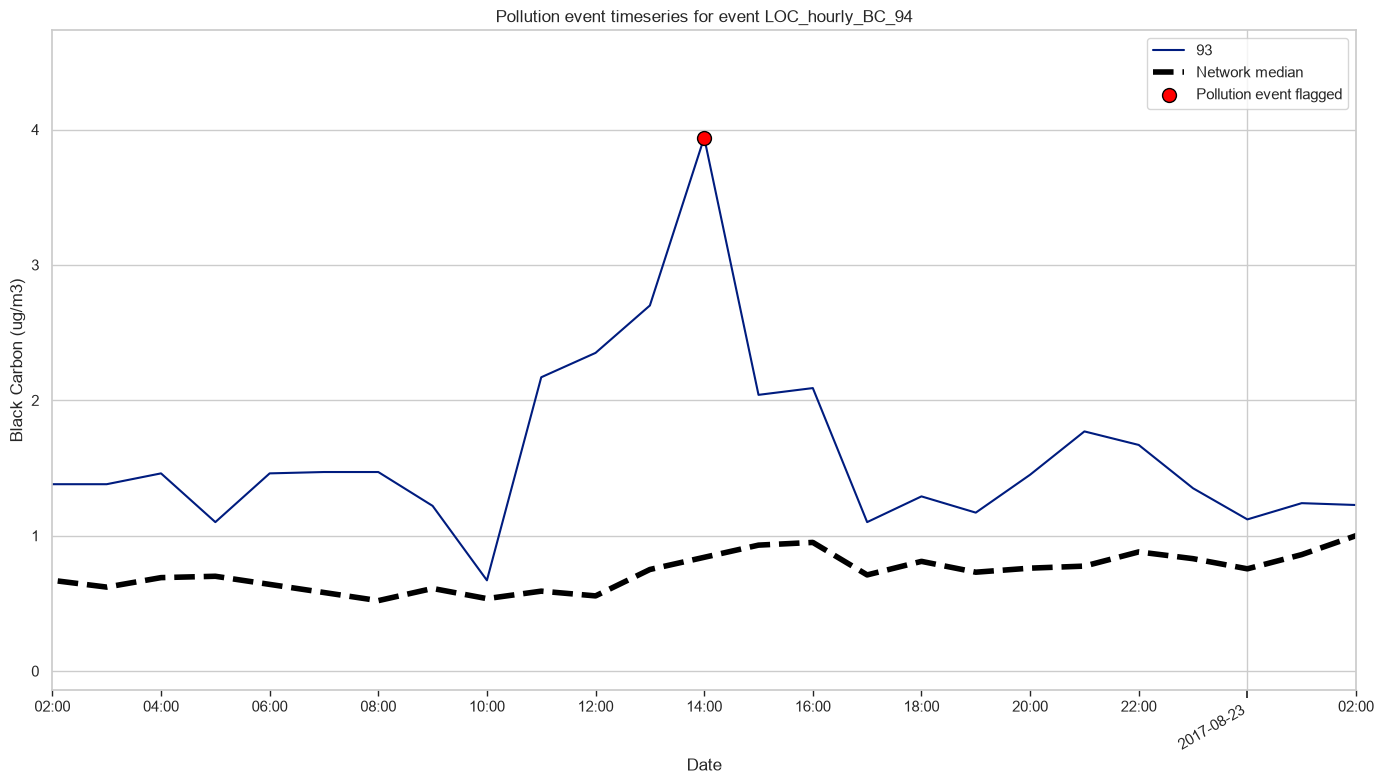

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from datetime import datetime, timedelta

event_of_interest = "LOC_hourly_BC_94"
event_to_plot = local_events[local_events["event_ID"]==event_of_interest]

sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(14, 8))

# Filter for sites matching our event of interest
event_sites = df[df["event_ID"]==event_of_interest]["Site"].unique()
event_hours = df[df["event_ID"]==event_of_interest]
# Return a single value per hour to plot the network median
network_median = df.groupby("Datetime")["network_median_value"].first().reset_index()

# Plot values for a sensor if it was involved in the event of interest
sns.lineplot(
    data=df[df["Site"].isin(event_sites)],
    x="Datetime",
    y="value",
    hue="Site",
    palette="dark",
    alpha=1.0,
    linewidth=1.5,
    ax=ax
)
# Plot the network median
sns.lineplot(
    data=network_median,
    x="Datetime",
    y="network_median_value",
    color="black",
    alpha=1,
    linewidth=4,
    linestyle="--",
    label="Network median",
    ax=ax
)
# Add a red circle onto hours flagged in the event
sns.scatterplot(
    data=event_hours,
    x="Datetime",
    y="value",
    color="red",
    edgecolor="black",
    s=100,
    linewidth=1,
    label="Pollution event flagged",
    legend=True,
    zorder=5,
    ax=ax
)

# Format labels
plt.title(f"Pollution event timeseries for event {event_of_interest}")
plt.xlabel("Date", fontsize=12)
plt.ylabel("Black Carbon (ug/m3)", fontsize=12)
# Find event start, midpoint, and end times
event_start_time = event_to_plot["Datetime"].min()
event_end_time = event_to_plot["Datetime"].max()
event_midpoint = event_start_time + (event_end_time - event_start_time) / 2
# Format major ticks to occur daily
ax.xaxis.set_major_locator(mdates.DayLocator(interval=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
# Format minor ticks to occur every 3 hours
ax.tick_params(axis="x", which="both", bottom=True)
ax.xaxis.set_minor_locator(mdates.HourLocator(interval=2))
ax.xaxis.set_minor_formatter(mdates.DateFormatter('%H:%M'))
# Set x-axis limits to roughly the day around the event
ax.set_xlim(event_start_time - timedelta(hours=12), event_end_time + timedelta(hours=12))

fig.autofmt_xdate()
plt.tight_layout()
plt.show()

<h4>Regional events</h4>

Let's look at the first regional event, "REG_hourly_BC_0", and the week surrounding it.

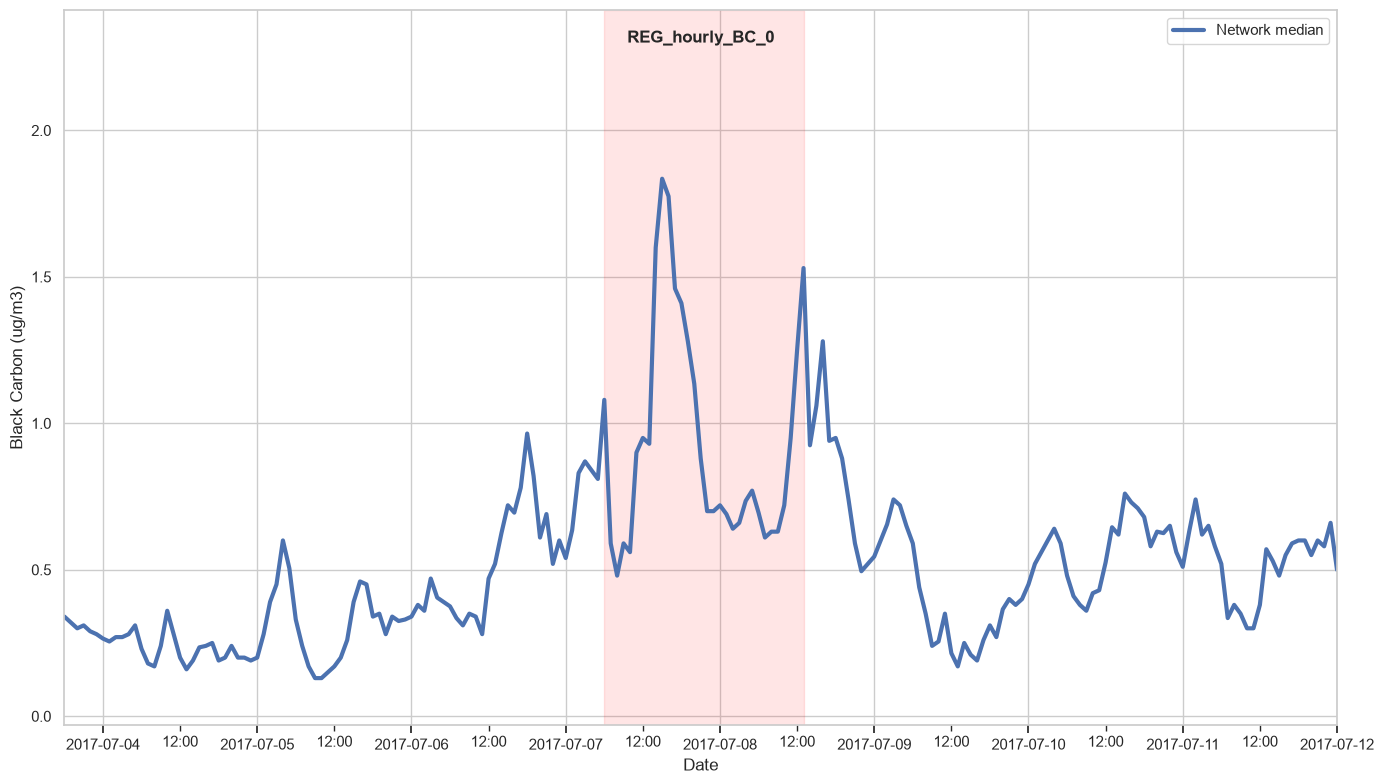

In [76]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from datetime import timedelta

event_of_interest = "REG_hourly_BC_0"

sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(14, 8))

# Plot the regional median value
sns.lineplot(
    data=network_median,
    x="Datetime",
    y="network_median_value",
    linewidth=3,
    label="Network median",
    ax=ax
)

# Filter data and find event start, midpoint, and end times
event_to_plot = regional_events[regional_events["event_ID"]==event_of_interest]
event_start_time = event_to_plot["Datetime"].min()
event_end_time = event_to_plot["Datetime"].max()
event_midpoint = event_start_time + (event_end_time - event_start_time) / 2

# Shade the regional event times in red 
ax.axvspan(event_start_time,
           event_end_time + timedelta(hours=1),
           color="red",
           alpha=0.1,
           label=event_of_interest)

# Place the event ID in the shaded area near the top of the figure 
event_text_y = ax.get_ylim()[1] * 0.96
ax.text(x=event_midpoint,
        y=event_text_y,
        s=event_of_interest,
        horizontalalignment='center', 
        verticalalignment='center',
        fontweight='bold')

# Format labels
ax.set_xlabel("Date", fontsize=12)
ax.set_ylabel("Black Carbon (ug/m3)", fontsize=12)
# Format major ticks to occur daily
ax.xaxis.set_major_locator(mdates.DayLocator(interval=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
# Format minor ticks to occur every 12 hours
ax.tick_params(axis="x", which="both", bottom=True)
ax.xaxis.set_minor_locator(mdates.HourLocator(interval=12))
ax.xaxis.set_minor_formatter(mdates.DateFormatter('%H:%M'))
# Set x-axis limits to the week around the event
ax.set_xlim(event_start_time - timedelta(days=3, hours=12), event_end_time + timedelta(days=3, hours=12))

plt.tight_layout()
plt.show()